In [2]:
from sktime.datasets import load_from_tsfile_to_dataframe
import pandas as pd
import pywt
import numpy as np
import matplotlib.pyplot as plt

In [3]:
dataset_prefix = "data/data10_IC1_FM_label_wl_20_pw_0_unwo_dropped_1_1_ratio_full_data/TokenItaly_vers0/"
file_path_train = dataset_prefix + "TokenItaly_vers0_TRAIN.ts"
file_path_test = dataset_prefix + "/TokenItaly_vers0_TEST.ts"

x_train, y_train = load_from_tsfile_to_dataframe(file_path_train)
x_test, y_test = load_from_tsfile_to_dataframe(file_path_test)

In [4]:
x_train.head()

,dim_0
0,0 26.34 1 25.13 2 26.93 3 36.2...
1,0 129.86 1 149.01 2 90.76 3 ...
2,0 0.00 1 0.00 2 0.00 3 5.7...
3,0 0.00 1 0.00 2 17.85 3 ...
4,0 170.05 1 55.81 2 68.60 3 ...


In [5]:
x_test.head()

,dim_0
0,0 0.00 1 13.10 2 43.84 3 ...
1,0 32.43 1 25.71 2 79.22 3 3...
2,0 24.34 1 27.55 2 0.00 3 0.0...
3,0 0.00 1 0.00 2 0.00 3 0.0...
4,0 46.42 1 23.42 2 0.00 3 39.9...


In [6]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19880 entries, 0 to 19879
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   dim_0   19880 non-null  object
dtypes: object(1)
memory usage: 155.4+ KB


In [7]:
print(x_train.dtypes)

dim_0    object
dtype: object


In [9]:
sample = x_train.iloc[0].iloc[0]
signal = np.array(sample)


print(f"Signal:  {signal}")
print(f"Label :  {y_train[0]}")

Signal:  [26.34 25.13 26.93 36.21 33.6  35.82  0.   22.73 15.82 69.89 19.95 26.33
 42.32 44.87  0.    7.03 10.32  2.57 20.8   0.  ]
Label :  0


In [10]:
scales = np.arange(1, 11)
wavelet = 'morl'

coefficients, frequencies = pywt.cwt(signal, scales, wavelet)

print("CWT shape:", coefficients.shape)

CWT shape: (10, 20)


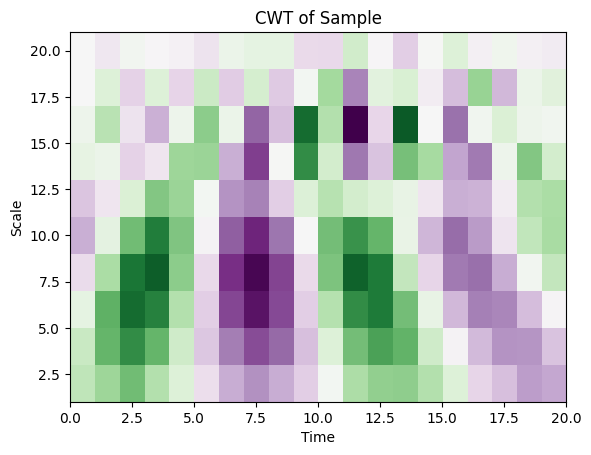

In [11]:
plt.imshow(coefficients, extent=[0, len(signal), 1, 21], cmap='PRGn', aspect='auto',
           vmax=abs(coefficients).max(), vmin=-abs(coefficients).max())
plt.title("CWT of Sample")
plt.ylabel('Scale')
plt.xlabel('Time')
plt.show()

# Data Prep

In [13]:
import numpy as np
import pywt
import torch
from torch.utils.data import Dataset, DataLoader
from sktime.datasets import load_from_tsfile_to_dataframe
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR

In [14]:
dataset_prefix = "data/data10_IC1_FM_label_wl_20_pw_0_unwo_dropped_1_1_ratio_full_data/TokenItaly_vers0/"
file_path_train = dataset_prefix + "TokenItaly_vers0_TRAIN.ts"
file_path_test = dataset_prefix + "/TokenItaly_vers0_TEST.ts"

x_train, y_train = load_from_tsfile_to_dataframe(file_path_train)
x_test, y_test = load_from_tsfile_to_dataframe(file_path_test)

In [15]:
def cwt_transform(signal, wavelet='morl', scales=np.arange(1, 21)):
    signal = np.array(signal)
    coefs, _ = pywt.cwt(signal, scales, wavelet)
    return coefs  # shape: [scale, time]

In [16]:
class CWTTimeSeriesDataset(Dataset):
    def __init__(self, x_df, y_list, wavelet, scales):
        self.samples = []
        self.labels = []

        for i in tqdm(range(len(x_df)), desc="Processing CWT"):
            ts = x_df.iloc[i].iloc[0]
            img = cwt_transform(ts, wavelet, scales)
            img = np.expand_dims(img, axis=0)  # shape: [1, scale, time]
            self.samples.append(torch.tensor(img, dtype=torch.float32))
            self.labels.append(int(y_list[i]))

    def plot(self, idx):
        img = self.samples[idx].squeeze(0).numpy()  # shape: [scale, time]
        plt.imshow(
            img,
            extent=[0, img.shape[1], 1, img.shape[0] + 1],
            cmap='PRGn',
            aspect='auto',
            vmax=abs(img).max(),
            vmin=-abs(img).max()
        )
        plt.title(f"CWT of Sample {idx}")
        plt.ylabel('Scale')
        plt.xlabel('Time')
        plt.colorbar(label='Amplitude')
        plt.show()

    def resize_images(self, new_size=(224, 224)):
        resized_samples = []
        for img in tqdm(self.samples, desc="Resizing images"):
            resized_img = F.interpolate(img.unsqueeze(0), size=new_size, mode='bilinear', align_corners=False)
            resized_samples.append(resized_img.squeeze(0))
        self.samples = resized_samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]


In [17]:
wavelet='morl'
scales=np.arange(1, 21)

train_dataset = CWTTimeSeriesDataset(x_train, y_train, wavelet, scales)
val_dataset = CWTTimeSeriesDataset(x_test, y_test, wavelet, scales)

# # Resize
# train_dataset.resize_images(new_size=(224, 224))
# val_dataset.resize_images(new_size=(224, 224))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Processing CWT: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4970/4970 [00:01<00:00, 3134.50it/s]


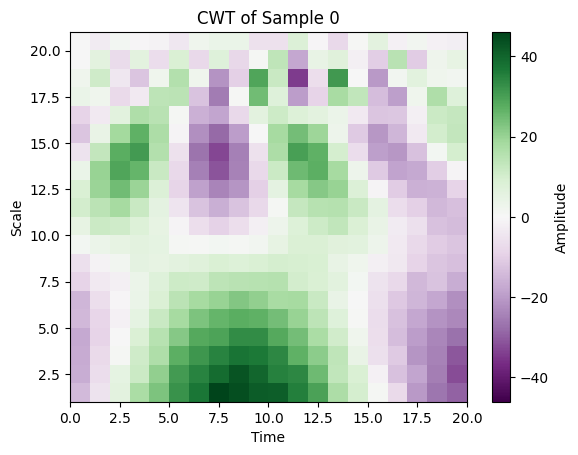

In [18]:
train_dataset.plot(idx=0)

# CNN Model

In [19]:
def CNN_model():
    model = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
        nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.2),

        nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.3),

        nn.Flatten(),
        nn.Linear(32 * 5 * 5, 128), nn.BatchNorm1d(128), nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128, 1),
        nn.Sigmoid()
    )
    return model

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'using device: {device}')

model = CNN_model().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=8, gamma=0.3)

epochs = 150

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training"):
        x, y = x.to(device), y.to(device).float().unsqueeze(1)

        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device).float().unsqueeze(1)

            logits_val = model(x_val)
            val_loss += criterion(logits_val, y_val).item()

            preds = (logits_val > 0.5).float()
            correct += (preds == y_val).sum().item()
            total += y_val.size(0)

    val_loss /= len(val_loader)
    val_accuracy = 100 * correct / total

    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {total_loss/len(train_loader):.4f}, "
          f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

    scheduler.step()

SyntaxError: '(' was never closed (2619918627.py, line 2)

# ViT

In [10]:
# Resize
train_dataset.resize_images(new_size=(224, 224))
val_dataset.resize_images(new_size=(224, 224))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Resizing images: 100%|█| 26892/26892 [00:03<00:00, 86
Resizing images: 100%|█| 6724/6724 [00:00<00:00, 9732


In [ ]:
# future works